# **Covid-19 XRAY images dataset**

### **Imports**

In [106]:
import torch
from torchvision import transforms
import warnings
import numpy as np
import random
from torchvision.transforms import ToTensor
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import os
import pandas as pd
import torchvision.datasets as dset
import torchvision.utils as vutils
from torch.utils.data import random_split, DataLoader 

# Model
import torch.nn as nn
import torch.nn.functional as F


# EDA
import matplotlib.pyplot as plt
from PIL import Image


warnings.filterwarnings("ignore")

# Set random seed for reproducibility
manualSeed = 999
#manualSeed = random.randint(1, 10000) # use if you want new results
print("Random Seed: ", manualSeed)
random.seed(manualSeed)
torch.manual_seed(manualSeed)
torch.use_deterministic_algorithms(True)



Random Seed:  999


### **Check GPU Availability**

In [107]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### **import dataset**

In [108]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [109]:
# import kagglehub
# import shutil
# import os

# cache_path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")
# project_data_path = "./dataset"

# # Create folder if it doesn't exist
# os.makedirs(project_data_path, exist_ok=True)

# # Step 4: copy from cache → your project
# shutil.copytree(cache_path, project_data_path, dirs_exist_ok=True)

# print("Dataset copied to:", project_data_path)

### **Global Variables**

In [110]:
dataset_root = "./dataset/COVID-19_Radiography_Dataset"
batch_size = 64
workers = 2
ngpu = 1

In [111]:
# Create the dataset
dataset = ImageFolder(root=dataset_root,
                           transform=transforms.Compose([
                               transforms.ToTensor(),
                           ]),
                           is_valid_file=lambda path: os.path.basename(os.path.dirname(path)) == 'images') # Ignores Mask images, for simplicity
dataset

Dataset ImageFolder
    Number of datapoints: 21165
    Root location: ./dataset/COVID-19_Radiography_Dataset
    StandardTransform
Transform: Compose(
               ToTensor()
           )

### **Train Test Splitting the dataset images**

The dataset is split 80:20 for training and testing respectively

In [112]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

### **Create DataLoader**

DataLoader is like a manager that manages how the data is retrieved, it makes batching the data easy for the CNN to load with later.

In [113]:
# Create the dataloader
train_dataloader = DataLoader(train_dataset, batch_size=batch_size,
                                         shuffle=True, num_workers=workers)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size,
                                         shuffle=False, num_workers=workers)

### **Exploratory Data Analysis**

#### **Bar chart to check for class imbalance**

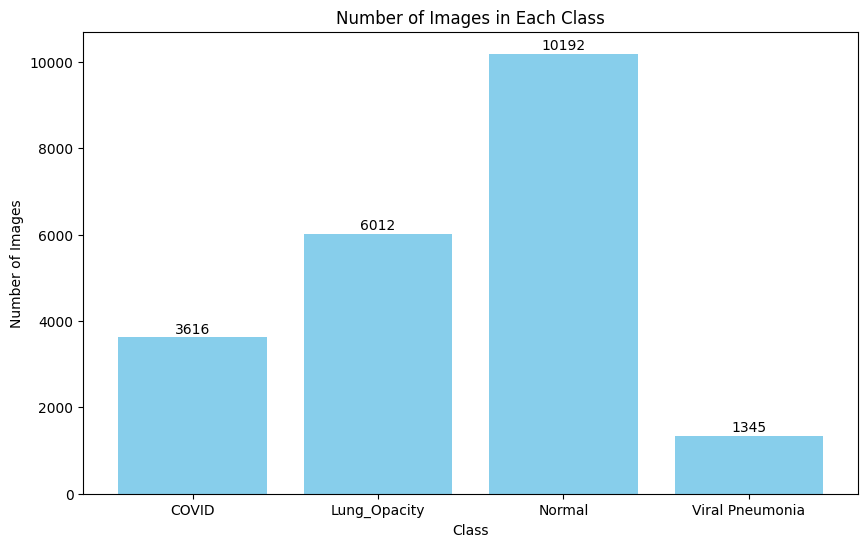

In [114]:
# The four classes in the dataset
classes = ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']

# Stores the number of images for each class
counts = []

# Go through each class and count how many images it has
for class_name in classes:
    # Get the path to the images folder for this class
    image_folder = os.path.join(dataset_root, class_name, 'images')

    # Count the number of image files inside the folder
    count = len(os.listdir(image_folder))

    # Add the count to the counts list
    counts.append(count)

plt.figure(figsize=(10, 6))
plt.bar(classes, counts, color='skyblue')

# Labels and titles
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Number of Images in Each Class')

# Loop for showing the numbers above the bars
for i in range(len(classes)):
    plt.text(i, counts[i] + 100, counts[i], ha='center')

# Display the chart
plt.show()


#### **Average image for each class**

Since the images in the directory are all already resized to 299x299, we do not have to take any actions to make sure their image size stays the same

In [115]:
# # Create a figure to show the average image for each class
# plt.figure(figsize=(14, 4))

# for i in range(len(classes)):
#     class_name = classes[i]

#     # Get the images folder for this class
#     image_folder = os.path.join(dataset_root, class_name, 'images')

#     # Get all image names in the folder
#     image_names = os.listdir(image_folder)

#     # Open the first image to get the image size
#     first_image_path = os.path.join(image_folder, image_names[0])
#     first_image = Image.open(first_image_path).convert('L')

#     # Create an empty image array to store the total pixel values
#     total_image = np.zeros(np.array(first_image).shape)

#     # Add all images in the class together
#     for image_name in image_names:
#         # Open the image and convert it to grayscale
#         image_path = os.path.join(image_folder, image_name)
#         image = Image.open(image_path).convert('L')

#         # Convert the image into a numpy array
#         image_array = np.array(image)

#         # Add this image's pixel values to the total
#         total_image = total_image + image_array

#     # Divide by the number of images to get the average image
#     average_image = total_image / len(image_names)

#     # Plot the average image for this class
#     plt.subplot(1, 4, i + 1)
#     plt.imshow(average_image, cmap='gray')
#     plt.title(class_name)
#     plt.axis('off')

# # Add the main title and show the plot
# plt.suptitle('Average Image for Each Class')
# plt.show()

The images seem to all show little to no differences across each other though there are subtle differences in lightness.

### **Creating the CNN model**

In [ ]:
class CNN(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        
        # Extract features
        self.conv1 = nn.Conv2d(3, 20, 1)
        self.batchNorm1 = nn.BatchNorm2d(20)
        self.ReLU1 = nn.ReLU()
        self.maxPool1 = nn.MaxPool2d(2, 2)
        
        # Classifier
        self.fc1 = nn.Linear(444020, 128)
        self.fc2 = nn.Linear(128, 4)

    def forward(self, x):
        print("start:", x.shape)

        x = self.conv1(x)


        x = self.batchNorm1(x)


        x = F.relu(x)


        x = self.maxPool1(x)


        x = x.view(x.size(0), -1)
        
        print("shape after flatten: ", x.shape)
        
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

loss = None
for epoch in range(5):
    for images, labels in train_dataloader:
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if loss is not None:
        print(f"Epoch {epoch} Loss: {loss.item()}")


start: torch.Size([64, 3, 299, 299])
shape after flatten:  torch.Size([64, 444020])
start: torch.Size([64, 3, 299, 299])
shape after flatten:  torch.Size([64, 444020])
start: torch.Size([64, 3, 299, 299])
shape after flatten:  torch.Size([64, 444020])
start: torch.Size([64, 3, 299, 299])
shape after flatten:  torch.Size([64, 444020])
start: torch.Size([64, 3, 299, 299])
shape after flatten:  torch.Size([64, 444020])
start: torch.Size([64, 3, 299, 299])
shape after flatten:  torch.Size([64, 444020])
start: torch.Size([64, 3, 299, 299])
shape after flatten:  torch.Size([64, 444020])
start: torch.Size([64, 3, 299, 299])
shape after flatten:  torch.Size([64, 444020])
start: torch.Size([64, 3, 299, 299])
shape after flatten:  torch.Size([64, 444020])
start: torch.Size([64, 3, 299, 299])
shape after flatten:  torch.Size([64, 444020])
start: torch.Size([64, 3, 299, 299])
shape after flatten:  torch.Size([64, 444020])
start: torch.Size([64, 3, 299, 299])
shape after flatten:  torch.Size([64, 4

In [ ]:
model.eval()

with torch.no_grad():
    sample, label = dataset[0]
    sample = sample.unsqueeze(0)  # add batch dim

    output = model(sample)
    predicted = torch.argmax(output, dim=1)

    print("Predicted:", predicted.item())

start: torch.Size([1, 3, 299, 299])
after conv1: torch.Size([1, 20, 299, 299])
after flatten: torch.Size([1, 1788020])
Predicted: 183307
